### Porting to Google Colab
The following cell enables this notebook to run from Google Colab as well as from your local machine IDE.<br>
You can change `root_directory` and/or `this_notebook_google_path` to point to the directory in your Google account, which contains this notebook, together with the `imgs` sub-directory and the rest of the files.<br>

In [1]:
import sys
import os
try:
    from google.colab import drive as google_drive # type: ignore
except:
    # no Google Colab --> fall back to local machine
    google_drive = None

if google_drive is not None:
    google_drive_directory = os.path.join('/','content','gdrive')
    google_drive.mount(google_drive_directory)
    all_projects_path = os.path.join(google_drive_directory, 'Othercomputers','My Laptop', 'projects')
elif os.name == 'posix': # Ubuntu
    all_projects_path = os.path.join(os.path.expanduser('~'), 'projects')
elif os.name == 'nt': # Windows
    all_projects_path = os.path.join('d:\\', 'projects')
else:
    raise EnvironmentError("Unsupported operating system")
    
project_path = os.path.join(all_projects_path,'RUNI','Thesis')
assert os.path.exists(project_path), f'Project path {project_path} not found!'
# enable import python files from this notebook's path
sys.path.append(project_path)
# enable reading images and data files from this notebook's path
os.chdir(project_path)

datasets_path = os.path.join(project_path, 'datasets')
assert os.path.exists(datasets_path), f'Datasets path {datasets_path} not found!'

output_path = os.path.join(project_path, 'output')
os.makedirs(output_path, exist_ok=True)
assert os.path.exists(output_path), f'Output path {output_path} not found!'
print(f'Current working directory: {os.getcwd()}')
print(f'Datasets path: {datasets_path}')
print(f'Output path: {output_path}')



Current working directory: /home/dror/projects/RUNI/Thesis
Datasets path: /home/dror/projects/RUNI/Thesis/datasets
Output path: /home/dror/projects/RUNI/Thesis/output


In [2]:
from python.hpc import HybridArray

Detecting CUDA version prior to importing numba...
Checking nvcc --version...
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Mon Aug 25 14:08:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.03              Driver Version: 575.64.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650        

/home/dror/venv/thesis3.13/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 50 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/dror/venv/thesis3.13/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 50 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


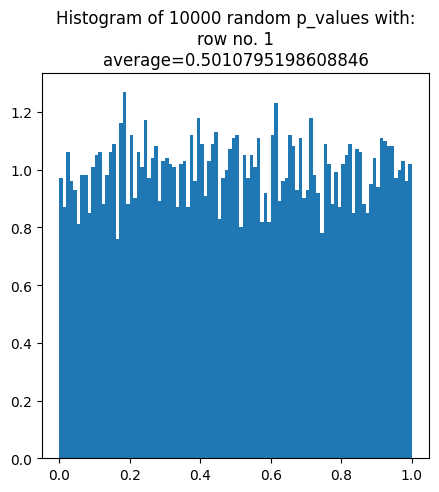

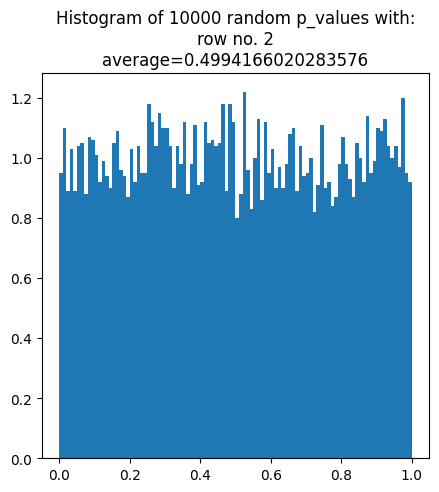

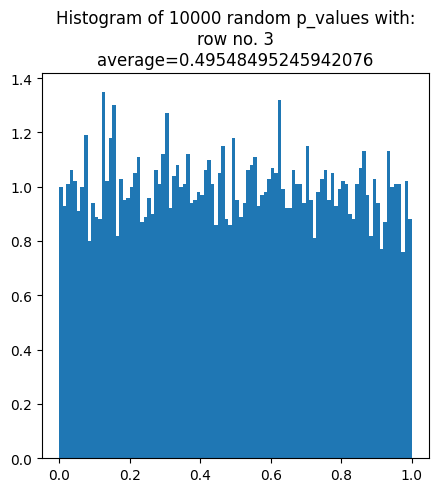

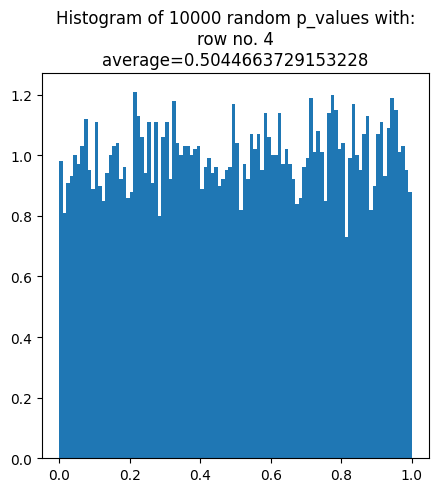

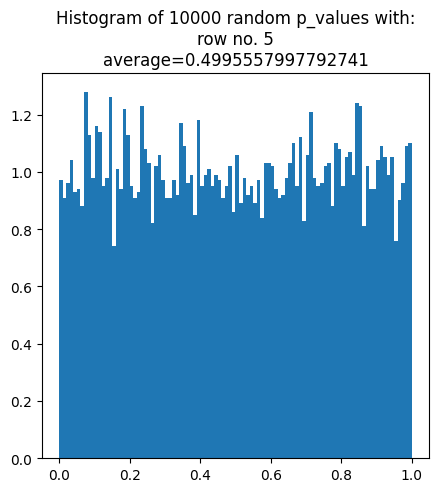

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from python.array_math_utils import average_column
from python.random_integers.random_integers import matrix, matrix_2_p_values
N = 10000
num_monte = 5
integers = HybridArray().realloc(shape=(num_monte,N), dtype=np.float64, use_gpu=True)
data_gpu = HybridArray()
matrix(data=integers, offset_row0=0, offset_col0=0)
matrix_2_p_values(integers=integers, p_values=data_gpu)
avg_column = HybridArray()
average_column(data_gpu, out_column=avg_column)
avg_numpy = avg_column.numpy().reshape(-1)
data_numpy = data_gpu.numpy()
bins = int(np.sqrt(N)+0.5)
for ind_row,x in enumerate(data_numpy):
    plt.figure(figsize=(5, 5))
    plt.hist(x=x, bins=bins, density=True)
    plt.title(f'Histogram of {N} random p_values with:\nrow no. {ind_row+1}\naverage={avg_numpy[ind_row]}')
    plt.show()
